# 4. Análisis final: hectáreas disponibles

Este capítulo **no forma parte del EDA ni del modelo de Machine Learning**. Usa el pronóstico de lluvia del capítulo 3 (la única variable estimada con ML: el agua que aporta la naturaleza) y los factores de la finca que se tratan como **constantes de entrada** (ver el capítulo anterior, *Factores tratados como constantes*).

El único resultado que se busca es el **número de hectáreas disponibles**: cuántas hectáreas de un cultivo de referencia se pueden sostener con el agua del reservorio y la lluvia pronosticada. No se decide qué cultivos sembrar ni cuánto de cada uno.

**Cálculo (por semana *w* del ciclo):**

- Demanda del cultivo de referencia por hectárea: $10 \cdot K_c \cdot ET_0$ (m³/ha). La $ET_0$ se calcula aquí con FAO-56 a partir de las variables del Excel; no se usó en el EDA ni en el modelo.
- Riego necesario por hectárea: $NR_w = \max(0,\ \text{demanda} - 10\,P^{ef}_w)/\eta$.
- Reservorio: $S_w = \min(J,\ S_{w-1} + 10\,P_w A_c C + Q_{ext} - NR_w\,x)$, con $S_0 = J$.
- **Hectáreas disponibles:** el mayor $x \le H$ con el que el reservorio nunca queda en negativo.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
np.random.seed(cfg.SEED)
plt.rcParams["figure.dpi"] = 110
from src import hidrologia as hy

faltan = cfg.faltantes(cfg.FINCA, "FINCA") + cfg.faltantes(cfg.LLUVIA_EFECTIVA, "LLUVIA_EFECTIVA") + \
         [f for c, d in cfg.CULTIVOS.items() for f in cfg.faltantes(d, f"CULTIVOS['{c}']")]
LISTO = not faltan
print("Constantes completas." if LISTO else "Constantes pendientes en src/config.py:\n  " + "\n  ".join(faltan))
CULTIVO_REF = list(cfg.CULTIVOS)[0]
pd.DataFrame({
    "constante": ["H (ha)", "J (m³)", "A_c (ha)", "C", "Q_ext (m³/semana)", "η", "α", "P_min (mm)", "cultivo de referencia",
                  "Kc inicial / medio / final", "etapas (días)"],
    "valor usado": [cfg.FINCA["H"], cfg.FINCA["J"], cfg.FINCA["A_c"], cfg.FINCA["C"], cfg.FINCA["Q_ext"], cfg.FINCA["eta"],
                    cfg.LLUVIA_EFECTIVA["alpha"], cfg.LLUVIA_EFECTIVA["P_min"], CULTIVO_REF,
                    " / ".join(str(cfg.CULTIVOS[CULTIVO_REF][k]) for k in ("Kc_ini", "Kc_mid", "Kc_end")),
                    " / ".join(str(cfg.CULTIVOS[CULTIVO_REF][k]) for k in ("L_ini", "L_dev", "L_mid", "L_late"))],
})

Constantes completas.


,constante,valor usado
0,H (ha),20
1,J (m³),20000
2,A_c (ha),0.5
3,C,1
4,Q_ext (m³/semana),0
5,η,0.9
6,α,0.8
7,P_min (mm),5
8,cultivo de referencia,maiz
9,Kc inicial / medio / final,0.3 / 1.2 / 0.35


## 4.1 Lluvia pronosticada y demanda del cultivo

Siembra en la semana siguiente al último dato (2026-01-01); ciclo de 18 semanas


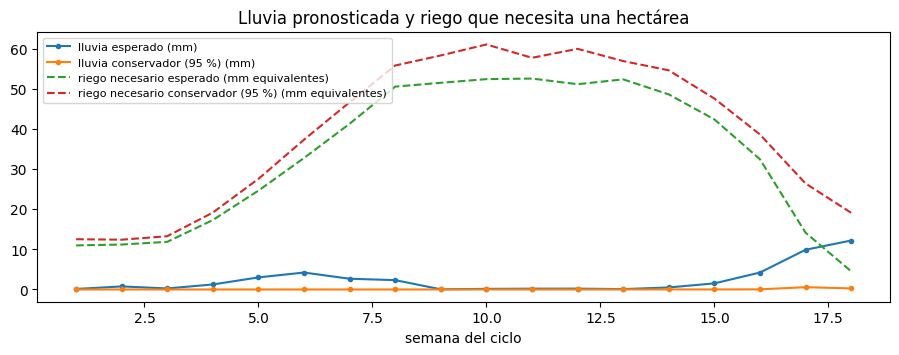

In [2]:
df = pd.read_csv(cfg.DATA_PROCESSED / cfg.ARCHIVO_DATOS, parse_dates=["fecha"])
g = df[df.punto == cfg.PUNTO_OBJETIVO].set_index("fecha").sort_index()
# ET0 FAO-56: construcción matemática usada solo en este análisis
g["ET0"] = hy.et0_penman_monteith(g.T2M_MAX, g.T2M_MIN, g.RH2M, g.WS2M, g.ALLSKY_SFC_SW_DWN, lat=cfg.LAT_FINCA,
                                  dia_juliano=g.index.dayofyear, elevacion_m=0.0, presion_kpa=g.PS)
pron = pd.read_csv(cfg.DATA_PROCESSED / "pronostico_lluvia_semanal.csv")
ultima = g.index.max()
et0_sem = g["ET0"].resample("W").sum(min_count=7).dropna()
woy = et0_sem.index.isocalendar().week.clip(upper=52).values
et0_q = pd.DataFrame({"et0": et0_sem.values, "woy": woy}).groupby("woy")["et0"]
semanas_woy = [min(52, int((ultima + pd.Timedelta(days=7 * s - 3)).isocalendar().week)) for s in pron.semana]
escenarios = {
    "esperado": {"P": pron["P_q500"].values, "ET0": et0_q.median().loc[semanas_woy].values},
    "conservador (95 %)": {"P": pron["P_q050"].values, "ET0": et0_q.quantile(0.95).loc[semanas_woy].values},
}
kc = hy.kc_semanal(cfg.CULTIVOS[CULTIVO_REF])
T = len(kc)
NR = {k: hy.necesidad_riego(kc, e["ET0"][:T], hy.lluvia_efectiva(e["P"][:T], **cfg.LLUVIA_EFECTIVA), cfg.FINCA["eta"])
      for k, e in escenarios.items()}
print(f"Siembra en la semana siguiente al último dato ({(ultima + pd.Timedelta(days=1)).date()}); ciclo de {T} semanas")
fig, ax = plt.subplots(figsize=(11, 3.5))
for k, e in escenarios.items():
    ax.plot(range(1, T + 1), e["P"][:T], marker="o", ms=3, label=f"lluvia {k} (mm)")
for k, v in NR.items():
    ax.plot(range(1, T + 1), v / 10, ls="--", label=f"riego necesario {k} (mm equivalentes)")
ax.set_xlabel("semana del ciclo"); ax.legend(fontsize=8); ax.set_title("Lluvia pronosticada y riego que necesita una hectárea"); plt.show()

## 4.2 Hectáreas disponibles

In [3]:
F = cfg.FINCA
filas = []
for k, e in escenarios.items():
    x = hy.area_maxima_un_cultivo(NR[k], e["P"][:T], F["H"], F["J"], F["A_c"], F["C"], F["Q_ext"])
    sim = hy.simular_tanque([x], NR[k], e["P"][:T], F["J"], F["A_c"], F["C"], F["Q_ext"])
    filas.append({"escenario": k, "hectáreas disponibles": round(x, 2),
                  "riego total del ciclo (m³)": round(float(NR[k].sum() * x)),
                  "riego por hectárea (m³/ha)": round(float(NR[k].sum())),
                  "semana más crítica": int(sim.loc[sim.nivel_m3.idxmin(), "semana"])})
hectareas = pd.DataFrame(filas)
hectareas

,escenario,hectáreas disponibles,riego total del ciclo (m³),riego por hectárea (m³/ha),semana más crítica
0,esperado,3.35,20218,6037,18
1,conservador (95 %),2.83,20004,7062,18


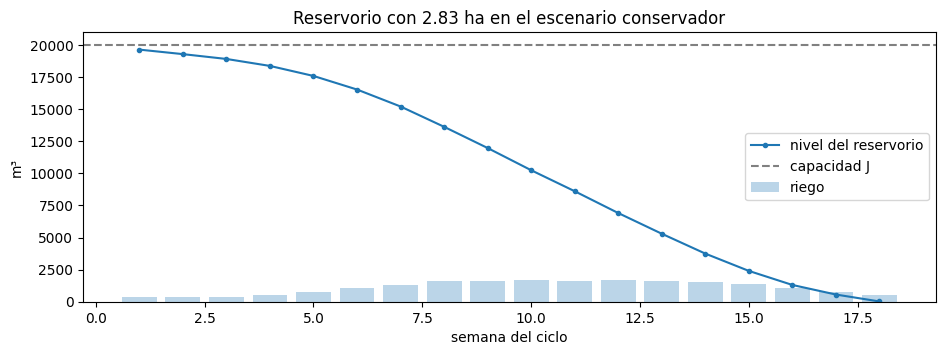

In [4]:
k = "conservador (95 %)"
x = float(hectareas.set_index("escenario").loc[k, "hectáreas disponibles"])
sim = hy.simular_tanque([x], NR[k], escenarios[k]["P"][:T], F["J"], F["A_c"], F["C"], F["Q_ext"])
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(sim.semana, sim.nivel_m3, marker="o", ms=3, label="nivel del reservorio")
ax.axhline(F["J"], ls="--", c="grey", label="capacidad J"); ax.bar(sim.semana, sim.consumo_m3, alpha=.3, label="riego")
ax.set_xlabel("semana del ciclo"); ax.set_ylabel("m³"); ax.legend(); ax.set_title(f"Reservorio con {x:.2f} ha en el escenario conservador"); plt.show()

## 4.3 Sensibilidad a las constantes de la finca

In [5]:
filas_s = []
for fJ in [0.5, 0.75, 1.0, 1.25, 1.5]:
    for eta in [0.6, 0.75, 0.9]:
        e = escenarios["conservador (95 %)"]
        nr = hy.necesidad_riego(kc, e["ET0"][:T], hy.lluvia_efectiva(e["P"][:T], **cfg.LLUVIA_EFECTIVA), eta)
        filas_s.append({"J (m³)": F["J"] * fJ, "η": eta,
                        "hectáreas": round(hy.area_maxima_un_cultivo(nr, e["P"][:T], F["H"], F["J"] * fJ, F["A_c"], F["C"], F["Q_ext"]), 2)})
pd.DataFrame(filas_s).pivot(index="J (m³)", columns="η", values="hectáreas")

η,0.6,0.75,0.9
J (m³),,,
10000.0,0.94,1.18,1.42
15000.0,1.42,1.77,2.12
20000.0,1.89,2.36,2.83
25000.0,2.36,2.95,3.54
30000.0,2.83,3.54,4.25


**Interpretación.** Con las constantes de ejemplo (reservorio de 20.000 m³ lleno al sembrar, riego por goteo) y siembra el 1 de enero, al inicio de la temporada seca, hay **3,35 ha disponibles** en el escenario esperado y **2,83 ha con 95 % de seguridad**. Cada hectárea necesita entre 6.000 y 7.100 m³ de riego en el ciclo de 18 semanas, porque casi no llueve entre enero y abril; por eso el límite lo pone el agua del reservorio y no la tierra disponible (20 ha). La sensibilidad muestra que el área crece casi en proporción a la capacidad del reservorio y a la eficiencia del riego: con 30.000 m³ y goteo serían 4,25 ha; con 10.000 m³ y riego por gravedad, menos de 1 ha. Estos números dependen de las constantes de ejemplo y deben recalcularse con los datos reales de la finca.